# 01 - Exploratory data analysis

Reads the parquet cache written by `python -m supply_pipeline prepare`.

In [1]:
import sys, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from supply_pipeline.config import load_config
cfg = load_config(ROOT / "config.toml")
p = cfg.paths
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
%matplotlib inline

In [2]:
weekly = pd.read_parquet(p.interim_dir / "weekly.parquet")
series = pd.read_parquet(p.interim_dir / "series.parquet")
daily = pd.read_parquet(p.interim_dir / "daily.parquet")
inv = pd.read_parquet(p.interim_dir / "inventory_cedis_daily.parquet")
print(weekly.shape, series.shape, daily.shape, inv.shape)

(34793, 25) (328, 24) (245216, 16) (5502, 9)


## Coverage

In [3]:
display(series["cluster"].value_counts().sort_index().to_frame("series"))
display(series[["n_weeks", "mean_weekly", "on_hand_as_of"]].describe().round(1))
display(pd.read_csv(p.tables_dir / "coverage_inventory_by_date.csv", index_col=0))

,series
cluster,
A-X,6
A-Y,114
A-Z,80
B-Y,32
B-Z,90
C-Z,6


,n_weeks,mean_weekly,on_hand_as_of
count,328.0,328.0,321.0
mean,106.1,6878.4,25807.4
std,5.8,12592.5,38490.8
min,42.0,15.9,2.0
25%,107.0,463.8,2949.0
50%,107.0,1593.7,7370.0
75%,107.0,6327.3,30056.0
max,107.0,70106.8,172445.0


,rows,upcs,stores
date,,,
2026-03-20,84653,63,2857
2026-03-21,84653,63,2857
2026-03-22,84667,63,2857
2026-03-23,84668,63,2857
2026-03-24,84668,63,2857
2026-03-25,84668,63,2857
2026-03-26,84668,63,2857
2026-03-27,87522,67,2858
2026-03-28,87521,67,2858


## Cluster-level weekly sell-out

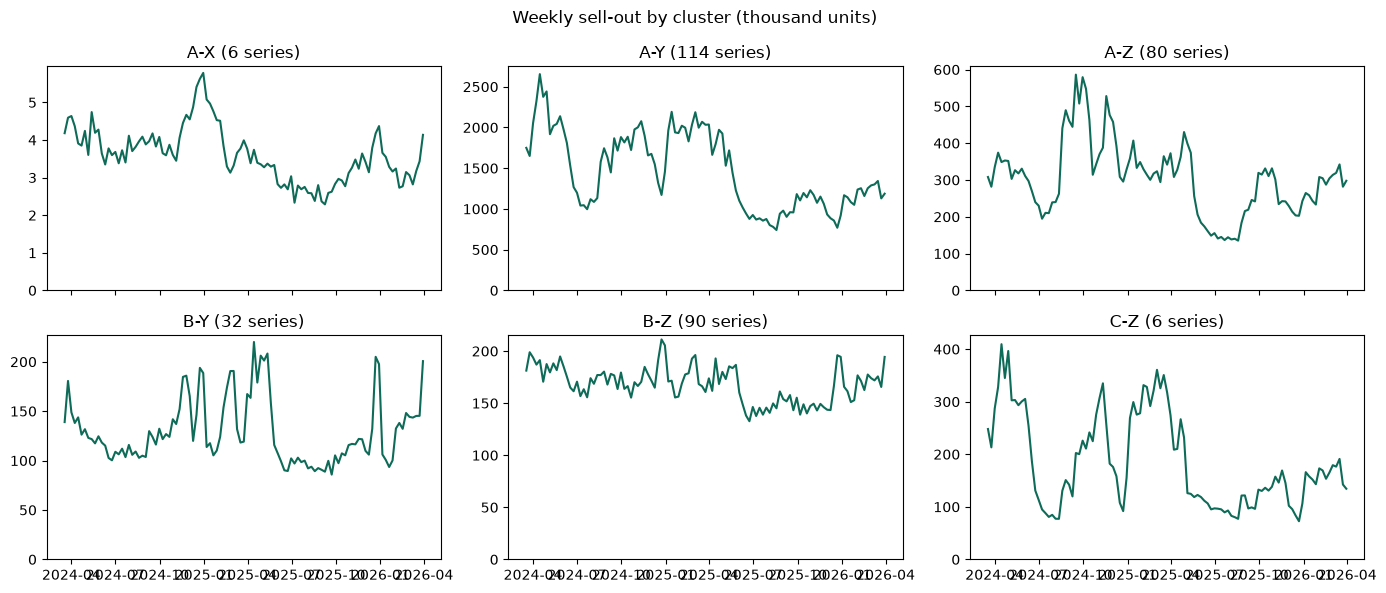

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for ax, (cl, g) in zip(axes.ravel(), weekly.groupby("cluster")):
    tot = g.groupby("week_start")["y"].sum()
    ax.plot(tot.index, tot.values / 1e3, color="#0E6B58"); ax.set_title(f"{cl} ({g[['upc','cedis']].drop_duplicates().shape[0]} series)"); ax.set_ylim(0)
fig.suptitle("Weekly sell-out by cluster (thousand units)"); fig.tight_layout()

## Promo lift and price

median promo lift: 0.99  share of promo days: 0.12


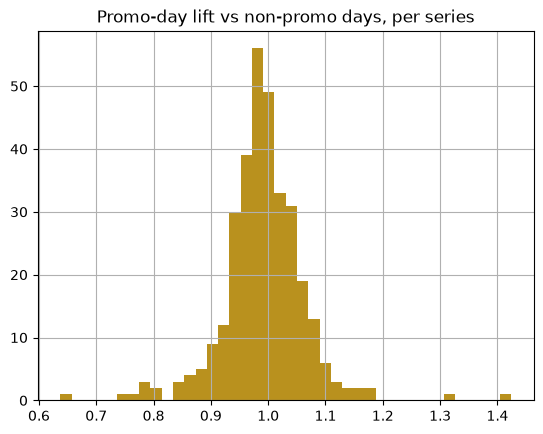

In [5]:
d = daily[daily["sell_out_pzs"].notna()].copy()
base = d[d["promo_flag"] == 0].groupby(["upc", "cedis"])["sell_out_pzs"].mean().rename("base")
promo = d[d["promo_flag"] == 1].groupby(["upc", "cedis"])["sell_out_pzs"].mean().rename("promo")
lift = pd.concat([base, promo], axis=1).dropna()
lift["lift"] = lift["promo"] / lift["base"]
print("median promo lift:", round(lift["lift"].median(), 2), " share of promo days:", round(d["promo_flag"].mean(), 3))
lift["lift"].clip(0, 5).hist(bins=40, color="#B9911E"); plt.title("Promo-day lift vs non-promo days, per series");

## Calendar effects

In [6]:
d["dow"] = d["date"].dt.dayofweek
rel = d.groupby(["upc", "cedis"])["sell_out_pzs"].transform(lambda s: s / s.mean())
print("weekday index:", d.assign(rel=rel).groupby("dow")["rel"].mean().round(3).to_dict())
for col in ["is_payday_window", "is_holiday", "is_semana_santa", "is_buen_fin", "is_december_peak"]:
    print(f"{col:20s} index = {d.assign(rel=rel).groupby(col)['rel'].mean().round(3).to_dict()}")

weekday index: {0: 1.049, 1: 0.972, 2: 0.804, 3: 0.794, 4: 0.895, 5: 1.129, 6: 1.362}
is_payday_window     index = {0: 0.979, 1: 1.087}
is_holiday           index = {0: 0.997, 1: 1.123}
is_semana_santa      index = {0: 0.994, 1: 1.183}
is_buen_fin          index = {0: 0.998, 1: 1.217}
is_december_peak     index = {0: 1.003, 1: 0.932}


## Inventory window

In [7]:
print(inv["stockout_store_share"].describe(percentiles=[.5, .9, .95, .99]).round(3))
print("series with >=25% stores at zero on any day:", inv[inv["stockout_store_share"] >= 0.25].groupby(["upc", "cedis"]).ngroups)
display(series.loc[series["is_discontinued"], ["upc", "cedis", "cluster", "mean_weekly", "tail4_mean"]])

count    5502.000
mean        0.063
std         0.127
min         0.000
50%         0.036
90%         0.093
95%         0.193
99%         1.000
max         1.000
Name: stockout_store_share, dtype: float64
series with >=25% stores at zero on any day: 17


,upc,cedis,cluster,mean_weekly,tail4_mean
25,539153751156,CMD2,A-Z,194.376203,0.250000
62,750101310119,TLJ,A-Z,155.743697,0.000000
144,750101310448,CMD2,A-Z,1085.001770,0.000000
145,750101310448,TLJ,A-Z,159.144780,6.021346
310,750101310955,CCUL,B-Z,106.846947,0.683693
311,750101310955,CMD2,B-Z,578.429927,1.347178
321,750101310997,VHSA,B-Z,51.337046,0.000000
